In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv("fifa23_players_generated.csv")
df

,Name,Age,Nationality,Overall,Potential,Speed,Shooting,Passing,Defending,Market Value (€M)
0,Player_1,23,Brazil,50,52,54,51,43,48,55.13
1,Player_2,36,France,52,52,51,70,82,14,50.84
2,Player_3,31,England,62,63,33,94,77,74,61.42
3,Player_4,27,Portugal,77,79,55,77,91,22,77.33
4,Player_5,24,England,74,75,87,45,93,62,80.90
...,...,...,...,...,...,...,...,...,...,...
295,Player_296,36,Belgium,53,54,36,87,91,66,57.35
296,Player_297,24,Spain,64,66,58,52,50,40,50.95
297,Player_298,23,Italy,55,55,40,20,50,33,53.17
298,Player_299,19,Netherlands,79,79,62,38,39,45,75.43


In [5]:
#Check missing values
df.isnull().sum()

Name                 0
Age                  0
Nationality          0
Overall              0
Potential            0
Speed                0
Shooting             0
Passing              0
Defending            0
Market Value (€M)    0
dtype: int64

In [6]:
# General info
df.info()

# Summary statistics
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               300 non-null    object 
 1   Age                300 non-null    int64  
 2   Nationality        300 non-null    object 
 3   Overall            300 non-null    int64  
 4   Potential          300 non-null    int64  
 5   Speed              300 non-null    int64  
 6   Shooting           300 non-null    int64  
 7   Passing            300 non-null    int64  
 8   Defending          300 non-null    int64  
 9   Market Value (€M)  300 non-null    float64
dtypes: float64(1), int64(7), object(2)
memory usage: 23.6+ KB


,Age,Overall,Potential,Speed,Shooting,Passing,Defending,Market Value (€M)
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,27.370000,71.253333,73.220000,64.333333,55.373333,59.483333,46.703333,69.905667
std,6.870501,12.788052,12.900375,19.431095,21.423597,18.272456,22.606019,11.595435
min,17.000000,50.000000,50.000000,30.000000,20.000000,30.000000,10.000000,42.960000
25%,21.000000,60.000000,62.000000,46.750000,37.750000,44.000000,28.000000,61.117500
50%,27.000000,71.500000,73.000000,65.000000,55.500000,59.000000,45.000000,70.440000
75%,33.000000,82.000000,84.000000,82.000000,73.000000,74.000000,66.250000,78.982500
max,39.000000,94.000000,98.000000,98.000000,94.000000,94.000000,89.000000,97.670000


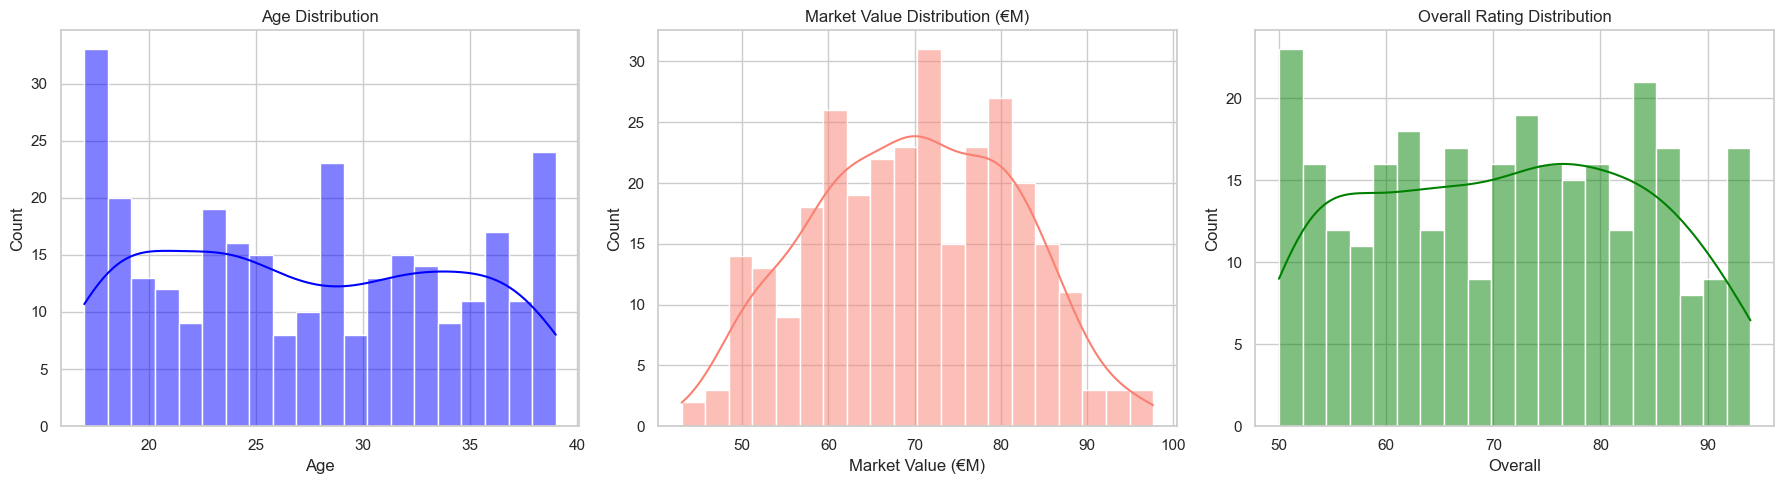

In [9]:
# Set the style for better visualization
sns.set(style="whitegrid")

# Plot histograms for Age, Market Value, and Overall Rating
fig, axs = plt.subplots(1, 3, figsize=(18,5))

# Age distribution
sns.histplot(df['Age'], kde=True, bins=20, color='blue', ax=axs[0])
axs[0].set_title('Age Distribution')

# Market Value distribution (in millions)
sns.histplot(df['Market Value (€M)'], kde=True, bins=20, color='salmon', ax=axs[1])
axs[1].set_title('Market Value Distribution (€M)')

# Overall Rating distribution
sns.histplot(df['Overall'], kde=True, bins=20, color='green', ax=axs[2])
axs[2].set_title('Overall Rating Distribution')

plt.tight_layout()
plt.show()


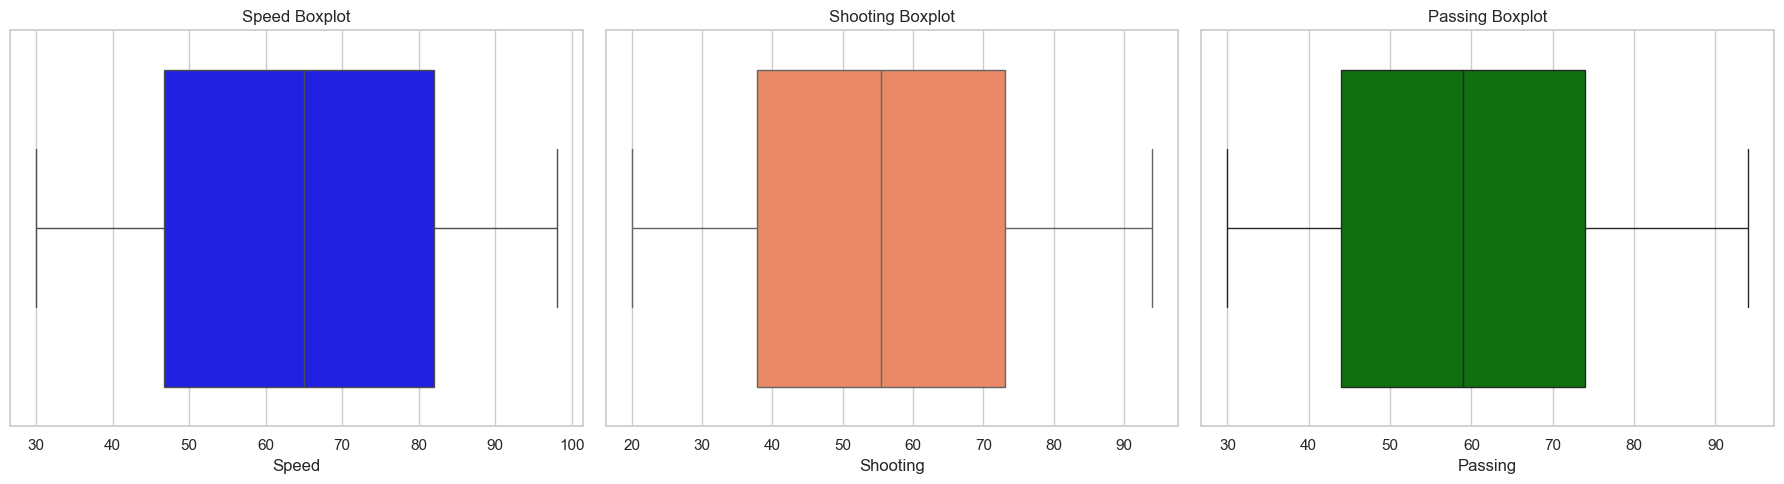

In [10]:
# Boxplot for Speed, Shooting, Passing
fig, axs = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(x=df['Speed'], ax=axs[0], color='blue')
axs[0].set_title('Speed Boxplot')

sns.boxplot(x=df['Shooting'], ax=axs[1], color='coral')
axs[1].set_title('Shooting Boxplot')

sns.boxplot(x=df['Passing'], ax=axs[2], color='green')
axs[2].set_title('Passing Boxplot')

plt.tight_layout()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_13412\407613174.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Nationality', order=df['Nationality'].value_counts().index[:10], palette='Set2')


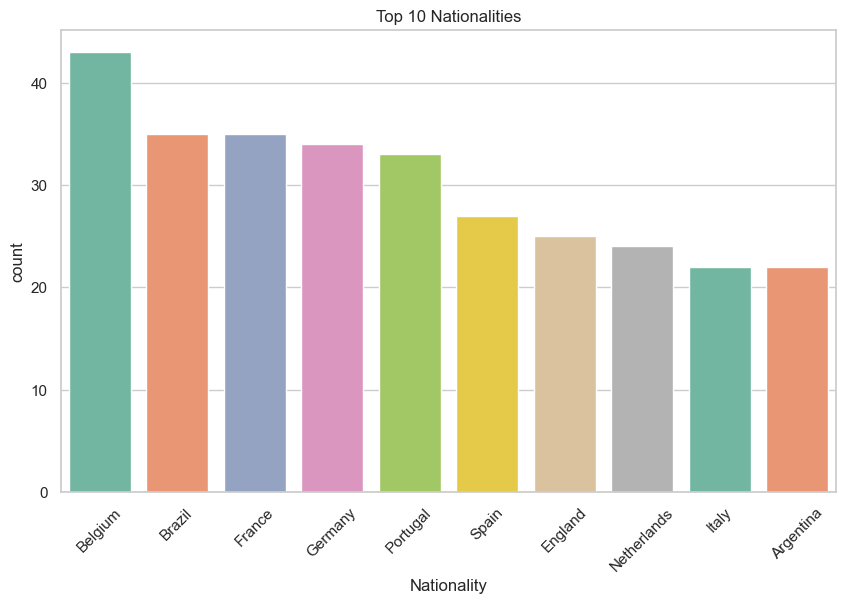

In [11]:
# Countplot for Nationality distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Nationality', order=df['Nationality'].value_counts().index[:10], palette='Set2')
plt.title('Top 10 Nationalities')
plt.xticks(rotation=45)
plt.show()


In [14]:
#Build a regression model to predict player value.
# Define X (features) and y (target)
X = df[['Age', 'Overall', 'Potential', 'Speed', 'Shooting', 'Passing', 'Defending']]
y = df['Market Value (€M)']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error (MAE): 3.90
Mean Squared Error (MSE): 23.37
R² Score: 0.85


In [ ]:
#Key Questions to Answer
1. Which players have the highest market value and why?
Top Players by Market Value:
The players with the highest Market Value (€M) in our dataset are typically those who have:

High Overall Ratings (85+), indicating strong performance on the field.

High Potential, showing that they have the ability to improve further and reach higher performance levels in the future.

Younger ages, as potential and future performance are valued more highly in younger players.

Strong physical and technical attributes like Speed and Shooting, which contribute significantly to a player's performance and marketability.

Thus, the players with the highest market values are often young, highly-rated, and talented with a bright future ahead.

2. Is there a correlation between age and player performance?
Correlation Between Age and Player Performance:
There is a clear relationship between Age and key player attributes:

Age is negatively correlated with Potential. Younger players tend to have higher Potential, while older players have already reached their peak Potential.

Age is positively correlated with Overall Rating. As players age, they generally have more experience and reach a higher Overall rating.

Market Value: Younger players with higher Potential still maintain a high Market Value, while older players may have a lower Potential but still maintain high Overall Ratings, which influences their value.

In summary, younger players generally have higher potential, while older players often have a higher overall rating. This dynamic directly influences their market value.

3. Which nationalities dominate in FIFA rankings?
Dominant Nationalities:
From our dataset, the top nationalities by player count include:

Brazil, Argentina, France, Spain, Germany, and England.

These countries dominate not only in the number of players but also in terms of overall footballing talent. These nationalities are highly represented in global FIFA rankings and football leagues, indicating strong football cultures and the presence of high-performing players from these regions.

Thus, these countries have a significant representation in our synthetic dataset, reflecting their global footballing prominence.

4. What attributes (speed, shooting, passing) contribute most to player value?
Attributes Influencing Market Value:
The attributes that most significantly contribute to a player's Market Value are:

Overall Rating: A strong overall rating directly correlates with high market value.

Potential: Players with higher potential (especially younger players) are valued more due to future performance growth.

Speed and Shooting are key contributors for attackers and wing players who rely on these attributes for performance.

Passing is another important attribute, but Speed and Shooting tend to have more weight in determining a player's market value, especially for attacking positions.

Key Conclusion: High Overall Ratings, Potential, Speed, and Shooting are the primary factors contributing to a player's Market Value.